
 >>> BEST STRATEGY: Strategy C (QQQ + RSI/MACD) <<<



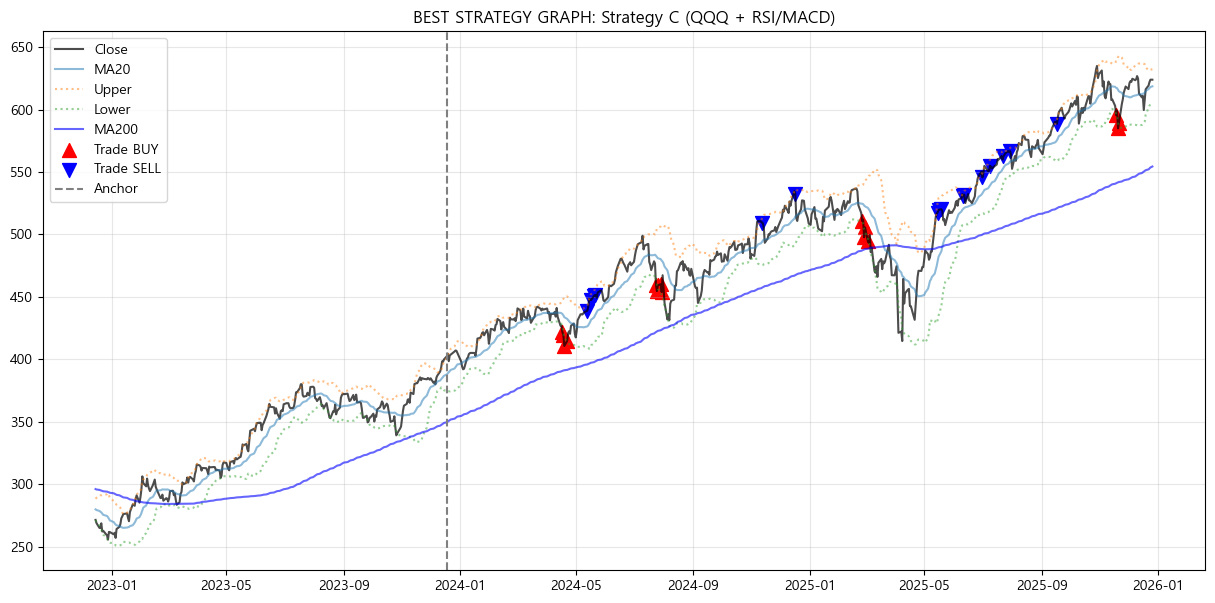


 [JUDGEMENT] 최선의 전략 판단
선정된 전략: Strategy C (QQQ + RSI/MACD)
판단 근거: 시뮬레이션 종료일 기준 가장 높은 최종 자산(Total Equity) 달성
최종 자산: $103,861.21

 [SUMMARY] Best Strategy 요약 및 실행 가이드
Date: 2025-12-26
Close: 55.31 (SignalZ: 0.77)
Holdings: Core=1565.38주, Trade=282.47주
Cash Pool: $1,657.01
👉 ACTION: HOLD / DCA Only

 [COMPARISON] 타 전략 대비 수익 비교
STRATEGY                            | FINAL EQUITY    | DIFF (vs BEST) 
---------------------------------------------------------------------------
* Strategy C (QQQ + RSI/MACD)       | $103,861        | $0 (0.0%)
  Strategy A (TQQQ 판단)              | $103,330        | $-531 (-0.5%)
  Strategy B (QQQ 판단)               | $102,996        | $-865 (-0.8%)
---------------------------------------------------------------------------
* 표시가 최선안입니다.


In [ ]:
# 1. 매일 사는 종목 (TQQQ) 매수/매도 포지션 코드
# NOTE:
# - 본 파일은 원본(251226_DCA.py)의 동작(Strategy A)을 그대로 유지하면서,
#   1) Strategy B: 추세판단(MA200 & Z-score)만 QQQ로 판단(체결/평가/코어 DCA는 TQQQ)
#   2) Strategy C: Strategy B를 기반으로 RSI/MACD 조건을 추가한 신호(체결/평가/코어 DCA는 TQQQ)
#   3) Strategy D: Strategy C와 동일한 RSI/MACD 조건을 "TQQQ로 판단"(즉 Strategy A에서 RSI/MACD 추가)
# 를 추가하여 A/B/C/D를 동일한 형식으로 비교할 수 있도록 확장한 버전입니다.

# Jupyter에서 "%matplotlib inline"과 동일한 효과(스크립트 실행 시에는 무시)
try:
    get_ipython().run_line_magic("matplotlib", "inline")  # type: ignore
except Exception:
    pass

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# =========================
# 설정
# =========================
TICKER = "TQQQ"          # 체결/평가/코어 DCA 종목(원본 유지)
SIGNAL_TICKER = "QQQ"    # Strategy B/C에서 추세판단(MA200 & Z-score) 및 RSI/MACD 산출 종목

# 지표(밴드/추세)
BB_WINDOW = 20
BB_K = 2.0
MA200_W = 200

# 신호 기준(원본)
ADD_BUY_Z = -1.5
SELL_Z1   =  1.5
SELL_Z2   =  2.0

# Strategy C/D 추가 신호 기준
RSI_PERIOD = 14
RSI_BUY_NORMAL = 40.0   # 과매도(완화) 기준: RSI < 40 동반 시에만 매수
RSI_BUY_CRASH  = 30.0   # 극단적 공포 기준: RSI < 30이면 200일선 아래라도 매수 허용

# MACD(표준 파라미터)
MACD_FAST = 12
MACD_SLOW = 26
MACD_SIGNAL = 9

# 코어 DCA(매일) - 원본 유지
DCA_DOLLARS_PER_DAY = 7.0

# 트레이딩 매매 비율(수량 기준) - 트레이딩 레이어 보유분에서만 매도 - 원본 유지
SELL1_FRACTION = 0.25
SELL2_FRACTION = 0.50

# 트레이딩 매수 집행 규칙(현금풀에서만) - 원본 유지
TRADE_BUY_USE_FRACTION = 0.40  # 신호 발생 시 현금풀의 50% 사용
MIN_TRADE_BUY_DOLLARS = 50.0  # 현금풀이 너무 작으면 패스

# 데이터
PERIOD = "5y"
INTERVAL = "1d"

# 실제 계좌 기준점 (휴장일이면 가장 가까운 이전 거래일을 앵커로 사용) - 원본 유지
START_DATE = "2024-01-19"

# 실제 계좌 기준(원본 유지)
INITIAL_EQUITY = 223.57       # 2025-12-18 기준 평가금액
INITIAL_TRADE_CASH = 5000.0
INITIAL_TRADE_SHARES = 0.0

# 그래프 표시용 룩백(앵커일 이전 N 거래일을 함께 보여줌)
LOOKBACK_BARS = 252  # 1년 거래일 정도 (원하면 180 등으로 조정)

# =========================
# 유틸
# =========================
def _download_ohlc(ticker: str) -> pd.DataFrame:
    df = yf.download(
        ticker,
        period=PERIOD,
        interval=INTERVAL,
        auto_adjust=True,
        group_by="column",
        progress=False
    ).dropna()

    # yfinance가 MultiIndex 컬럼을 주는 경우가 있어 평탄화
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    if "Close" not in df.columns:
        raise ValueError(f"{ticker}: Close 컬럼이 없습니다. 데이터 로드를 확인하세요.")

    return df


def _calc_rsi(close: pd.Series, period: int = RSI_PERIOD) -> pd.Series:
    """
    Wilder 방식에 준하는 RSI 계산(ewm smoothing).
    """
    close = close.astype(float)
    delta = close.diff()
    gain = delta.clip(lower=0.0)
    loss = (-delta).clip(lower=0.0)

    avg_gain = gain.ewm(alpha=1.0 / period, adjust=False, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1.0 / period, adjust=False, min_periods=period).mean()

    rs = avg_gain / avg_loss
    rsi = 100.0 - (100.0 / (1.0 + rs))

    # avg_loss=0 케이스 보정(무한대 -> RSI 100)
    rsi = rsi.replace([np.inf, -np.inf], np.nan)
    rsi = rsi.fillna(100.0)
    return rsi


def _add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """
    원본 지표(MA20/STD20/BB/MA200/Z)를 그대로 유지하면서,
    Strategy C/D용 RSI/MACD 지표를 추가합니다.
    """
    df = df.copy()
    close = df["Close"].astype(float)

    # Bollinger / Trend / Z
    df["MA20"]  = close.rolling(BB_WINDOW).mean()
    df["STD20"] = close.rolling(BB_WINDOW).std(ddof=0)
    df["Upper"] = df["MA20"] + BB_K * df["STD20"]
    df["Lower"] = df["MA20"] - BB_K * df["STD20"]
    df["MA200"] = close.rolling(MA200_W).mean()
    df["Z"]     = (close - df["MA20"]) / df["STD20"]

    # RSI
    df["RSI"] = _calc_rsi(close, RSI_PERIOD)

    # MACD histogram
    ema_fast = close.ewm(span=MACD_FAST, adjust=False).mean()
    ema_slow = close.ewm(span=MACD_SLOW, adjust=False).mean()
    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=MACD_SIGNAL, adjust=False).mean()
    macd_hist = macd - macd_signal
    df["MACD"] = macd
    df["MACDSignal"] = macd_signal
    df["MACDHist"] = macd_hist

    # 원본과 동일하게 dropna (MA200 등 선행구간 제거)
    df = df.dropna().copy()

    if len(df) < MA200_W + BB_WINDOW + 5:
        raise ValueError("데이터가 부족합니다. PERIOD를 더 늘려보세요(예: 10y).")

    return df


def _pick_anchor_date(df: pd.DataFrame, start_date: str) -> pd.Timestamp:
    start_ts = pd.Timestamp(start_date)
    df_before_or_on = df[df.index <= start_ts]
    if df_before_or_on.empty:
        raise ValueError("START_DATE 이전/당일 데이터가 없습니다. START_DATE/PERIOD를 확인하세요.")
    return df_before_or_on.index[-1]  # START_DATE 이전/당일의 마지막 거래일


def _nearest_or_on(df: pd.DataFrame, target_dt: pd.Timestamp) -> pd.Timestamp:
    """target_dt가 df.index에 없으면, target_dt 이전/당일의 마지막 거래일을 반환."""
    if target_dt in df.index:
        return target_dt
    idx = df.index.get_indexer([target_dt], method="pad")
    if idx[0] == -1:
        raise ValueError("지정일 이전/당일 데이터가 없습니다.")
    return df.index[idx[0]]


def _simulate(
    exec_df: pd.DataFrame,
    signal_df: pd.DataFrame,
    anchor_dt: pd.Timestamp,
    anchor_price: float,
    initial_equity: float,
    initial_trade_cash: float,
    initial_trade_shares: float,
    use_signal_ticker_for_judgement: bool,
    signal_rule: str = "BASE"
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    exec_df: 체결/평가에 사용할 종목 데이터(원본: TQQQ)
    signal_df: 추세판단(MA200 & Z-score) / RSI / MACD 산출용 데이터(원본: exec_df / B,C: QQQ)
    anchor_dt: 기준 거래일(원본과 동일하게 exec_df에서 산출)
    anchor_price: exec_df의 anchor_dt 종가
    use_signal_ticker_for_judgement:
        - False(Strategy A/D): exec_df(TQQQ)의 지표로 판단
        - True (Strategy B/C): signal_df(QQQ)의 지표로 판단
    signal_rule:
        - "BASE": 원본 신호(밴드/Z + MA200 필터)
        - "C": RSI/MACD 강화 신호(요청사항 반영)
    """
    # 시뮬 구간: 앵커일부터(원본 유지)
    df_sim = exec_df[exec_df.index >= anchor_dt].copy()
    if df_sim.empty:
        raise ValueError("df_sim이 비었습니다. date filter를 확인하세요.")

    # 신호용 데이터(Strategy B/C는 QQQ를 exec_df 날짜로 정렬)
    sig_aligned = signal_df.reindex(df_sim.index).ffill()

    # 신호 판단에 사용할 값
    if use_signal_ticker_for_judgement:
        df_sim["SIG_Close"] = sig_aligned["Close"].astype(float)
        df_sim["SIG_MA200"] = sig_aligned["MA200"].astype(float)
        df_sim["SIG_Z"]     = sig_aligned["Z"].astype(float)
        df_sim["SIG_RSI"]   = sig_aligned["RSI"].astype(float)
        df_sim["SIG_MACDH"] = sig_aligned["MACDHist"].astype(float)
    else:
        # TQQQ로 판단(Strategy A/D)
        df_sim["SIG_Close"] = df_sim["Close"].astype(float)
        df_sim["SIG_MA200"] = df_sim["MA200"].astype(float)
        df_sim["SIG_Z"]     = df_sim["Z"].astype(float)
        df_sim["SIG_RSI"]   = df_sim["RSI"].astype(float)
        df_sim["SIG_MACDH"] = df_sim["MACDHist"].astype(float)

    trend_up = df_sim["SIG_Close"] > df_sim["SIG_MA200"]

    if signal_rule.upper() == "BASE":
        # 원본 신호(Strategy A/B)
        df_sim["ADD_BUY"] = trend_up & (df_sim["SIG_Z"] <= ADD_BUY_Z)
        df_sim["SELL_1"]  = trend_up & (df_sim["SIG_Z"] >= SELL_Z1)
        df_sim["SELL_2"]  = trend_up & (df_sim["SIG_Z"] >= SELL_Z2)

    elif signal_rule.upper() == "C":
        # Strategy C/D 신호(강화)
        # 1) RSI: RSI<40 동반될 때만 매수
        # 2) 낙주 매매: RSI<30이면 200일선 아래라도 매수 허용
        # 3) MACD: 히스토그램 감소(오늘<어제)할 때만 매도
        buy_z = df_sim["SIG_Z"] <= ADD_BUY_Z
        buy_normal = trend_up & (df_sim["SIG_RSI"] < RSI_BUY_NORMAL)
        buy_crash = (df_sim["SIG_RSI"] < RSI_BUY_CRASH)  # MA200 아래라도 허용
        df_sim["ADD_BUY"] = buy_z & (buy_normal | buy_crash)

        macd_hist_decreasing = df_sim["SIG_MACDH"].diff() < 0
        df_sim["SELL_1"] = trend_up & (df_sim["SIG_Z"] >= SELL_Z1) & macd_hist_decreasing
        df_sim["SELL_2"] = trend_up & (df_sim["SIG_Z"] >= SELL_Z2) & macd_hist_decreasing

    else:
        raise ValueError(f"Unknown signal_rule: {signal_rule}")

    # =========================
    # 초기 포지션 주입 (네 실제 계좌를 앵커일 종가로 주식 수 역산) — 원본 유지
    # =========================
    core_shares = initial_equity / anchor_price
    trade_shares = float(initial_trade_shares)
    trade_cash = float(initial_trade_cash)

    # =========================
    # 시뮬레이션 (앵커일은 초기화한 날이라 DCA 스킵, 다음 거래일부터 DCA) — 원본 유지
    # =========================
    records = []

    for i, (dt, row) in enumerate(df_sim.iterrows()):
        price = float(row["Close"])  # 체결/평가 가격은 항상 exec_df(TQQQ)의 Close

        # 코어 DCA (앵커일 제외)
        core_buy_shares = 0.0
        if i > 0:
            core_buy_shares = DCA_DOLLARS_PER_DAY / price
            core_shares += core_buy_shares

        # 트레이딩 매도 우선(SELL_2 > SELL_1)
        did_trade_sell_shares = 0.0
        did_trade_sell_dollars = 0.0

        if bool(row["SELL_2"]) and trade_shares > 0:
            sell_shares = min(trade_shares, trade_shares * SELL2_FRACTION)
            trade_shares -= sell_shares
            proceeds = sell_shares * price
            trade_cash += proceeds
            did_trade_sell_shares = sell_shares
            did_trade_sell_dollars = proceeds

        elif bool(row["SELL_1"]) and trade_shares > 0:
            sell_shares = min(trade_shares, trade_shares * SELL1_FRACTION)
            trade_shares -= sell_shares
            proceeds = sell_shares * price
            trade_cash += proceeds
            did_trade_sell_shares = sell_shares
            did_trade_sell_dollars = proceeds

        # 트레이딩 매수(현금풀 일부 사용)
        did_trade_buy_shares = 0.0
        did_trade_buy_dollars = 0.0

        if bool(row["ADD_BUY"]) and trade_cash >= MIN_TRADE_BUY_DOLLARS:
            spend = trade_cash * TRADE_BUY_USE_FRACTION
            if spend >= MIN_TRADE_BUY_DOLLARS:
                buy_shares = spend / price
                trade_shares += buy_shares
                trade_cash -= spend
                did_trade_buy_shares = buy_shares
                did_trade_buy_dollars = spend

        # 평가
        core_value = core_shares * price
        trade_value = trade_shares * price
        total_value = core_value + trade_value + trade_cash

        records.append({
            "Date": dt,
            "Close": price,
            "Z": float(row["Z"]),                    # 표시용: exec_df(TQQQ)의 Z
            "SignalClose": float(row["SIG_Close"]),  # 판단에 쓰인 Close
            "SignalZ": float(row["SIG_Z"]),          # 판단에 쓰인 Z
            "SignalRSI": float(row["SIG_RSI"]),      # 판단에 쓰인 RSI
            "SignalMACDHist": float(row["SIG_MACDH"]),  # 판단에 쓰인 MACD hist
            "CoreShares": core_shares,
            "TradeShares": trade_shares,
            "TradeCash": trade_cash,
            "CoreValue": core_value,
            "TradeValue": trade_value,
            "TotalValue": total_value,
            "CoreBuyShares": core_buy_shares,
            "TradeBuyShares": did_trade_buy_shares,
            "TradeBuyDollars": did_trade_buy_dollars,
            "TradeSellShares": did_trade_sell_shares,
            "TradeSellDollars": did_trade_sell_dollars,
            "Signal_ADD_BUY": bool(row["ADD_BUY"]),
            "Signal_SELL_1": bool(row["SELL_1"]),
            "Signal_SELL_2": bool(row["SELL_2"]),
        })

    bt = pd.DataFrame(records).set_index("Date")
    return df_sim, bt


def _plot_price_with_signals(
    plot_df: pd.DataFrame,
    bt: pd.DataFrame,
    anchor_dt: pd.Timestamp,
    title: str
) -> None:
    # DCA 마커 (시뮬 구간에서 실제로 실행된 날만)
    dca_pts = bt[bt["CoreBuyShares"] > 0]
    trade_buys = bt[bt["TradeBuyDollars"] > 0]
    trade_sells = bt[bt["TradeSellDollars"] > 0]

    y_close = plot_df["Close"].reindex(bt.index)
    dca_y = y_close.reindex(dca_pts.index)
    buy_y = y_close.reindex(trade_buys.index)
    sell_y = y_close.reindex(trade_sells.index)

    fig, ax = plt.subplots(figsize=(15, 7))
    ax.plot(plot_df.index, plot_df["Close"], label="Close")
    ax.plot(plot_df.index, plot_df["MA20"], label="MA20")
    ax.plot(plot_df.index, plot_df["Upper"], label="BB Upper (20,2σ)")
    ax.plot(plot_df.index, plot_df["Lower"], label="BB Lower (20,2σ)")
    ax.plot(plot_df.index, plot_df["MA200"], label="MA200")

    ax.scatter(dca_pts.index, dca_y, marker="o", s=25, alpha=0.6, label="Core DCA $100 daily")
    ax.scatter(trade_buys.index, buy_y, marker="^", s=90, label="Trade BUY (cash pool)")
    ax.scatter(trade_sells.index, sell_y, marker="v", s=90, label="Trade SELL (to cash pool)")

    ax.axvline(anchor_dt, linestyle="--", linewidth=1, label="Anchor (baseline)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


def _plot_equity_comparison(bt_a: pd.DataFrame, bt_b: pd.DataFrame, bt_c: pd.DataFrame, bt_d: pd.DataFrame) -> None:
    idx = bt_a.index.union(bt_b.index).union(bt_c.index).union(bt_d.index)
    a = bt_a["TotalValue"].reindex(idx)
    b = bt_b["TotalValue"].reindex(idx)
    c = bt_c["TotalValue"].reindex(idx)
    d = bt_d["TotalValue"].reindex(idx)

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.plot(a.index, a.values, label="Strategy A: Original (TQQQ judgement)")
    ax.plot(b.index, b.values, label="Strategy B: QQQ judgement")
    ax.plot(c.index, c.values, label="Strategy C: QQQ judgement + RSI/MACD filters")
    ax.plot(d.index, d.values, label="Strategy D: TQQQ judgement + RSI/MACD filters")
    ax.set_title("Equity Curve Comparison (Core + Trade + Cash)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


def _print_action_guide(name: str, last_sig_row: pd.Series, last_bt_row: pd.Series) -> None:
    print(f"\n=== {name} Latest ===")
    print("Date:", pd.Timestamp(last_sig_row.name).date())

    print(f"{TICKER} Close (execution price):", round(float(last_sig_row["Close"]), 2),
          "| TQQQ Z:", round(float(last_sig_row["Z"]), 2))
    print("Signal Close:", round(float(last_sig_row["SIG_Close"]), 2),
          "| Signal Z:", round(float(last_sig_row["SIG_Z"]), 2),
          "| Signal RSI:", round(float(last_sig_row["SIG_RSI"]), 1),
          "| Signal MACDHist:", round(float(last_sig_row["SIG_MACDH"]), 4))

    print("Signals => ADD_BUY:", bool(last_sig_row["ADD_BUY"]),
          "SELL_1:", bool(last_sig_row["SELL_1"]), "SELL_2:", bool(last_sig_row["SELL_2"]))

    if bool(last_sig_row["SELL_2"]) and float(last_bt_row["TradeShares"]) > 0:
        print("\nAction: SELL strong (trade layer) - if market open and signal persists.")
    elif bool(last_sig_row["SELL_1"]) and float(last_bt_row["TradeShares"]) > 0:
        print("\nAction: SELL (trade layer) - if market open and signal persists.")
    elif bool(last_sig_row["ADD_BUY"]) and float(last_bt_row["TradeCash"]) >= MIN_TRADE_BUY_DOLLARS:
        print("\nAction: BUY (trade layer) using cash pool - if market open and signal persists.")
    else:
        print("\nAction: No trade-layer action now (only daily DCA runs).")


# =========================
# 데이터 로드 (원본: TQQQ)
# =========================
df = _download_ohlc(TICKER)
df = _add_indicators(df)

# START_DATE 기준 앵커 거래일(휴장 보정) — 원본 유지
anchor_dt = _pick_anchor_date(df, START_DATE)
anchor_price = float(df.loc[anchor_dt, "Close"])
print("anchor_dt:", anchor_dt.date(), "anchor_price:", round(anchor_price, 2))

# =========================
# Strategy A (Original - TQQQ 판단)
# =========================
df_sim_A, bt_A = _simulate(
    exec_df=df,
    signal_df=df,
    anchor_dt=anchor_dt,
    anchor_price=anchor_price,
    initial_equity=INITIAL_EQUITY,
    initial_trade_cash=INITIAL_TRADE_CASH,
    initial_trade_shares=INITIAL_TRADE_SHARES,
    use_signal_ticker_for_judgement=False,
    signal_rule="BASE"
)

# TQQQ 차트 표시 범위
anchor_pos = df.index.get_loc(anchor_dt)
start_pos = max(0, anchor_pos - LOOKBACK_BARS)
end_pos = df.index.get_loc(df_sim_A.index[-1]) + 1
df_plot_A = df.iloc[start_pos:end_pos].copy()

_plot_price_with_signals(
    plot_df=df_plot_A,
    bt=bt_A,
    anchor_dt=anchor_dt,
    title=f"{TICKER} | Strategy A (TQQQ judgement) | Baseline equity ${INITIAL_EQUITY} on {START_DATE} (anchor {anchor_dt.date()})"
)

print("\n=== Anchor (your real baseline) ===")
print("Requested START_DATE:", START_DATE)
print("Anchor trading date used:", anchor_dt.date())
print("Anchor Close:", round(anchor_price, 2))
print("Initial Equity:", INITIAL_EQUITY)
print("Initial CoreShares (equity/anchor_close):", round(INITIAL_EQUITY / anchor_price, 6))

last_sig_A = df_sim_A.iloc[-1]
last_bt_A = bt_A.iloc[-1]
_print_action_guide("Strategy A (Original - TQQQ judgement)", last_sig_A, last_bt_A)

# =========================
# QQQ 데이터 로드(Strategy B/C)
# =========================
df_sig = _download_ohlc(SIGNAL_TICKER)
df_sig = _add_indicators(df_sig)

anchor_dt_sig = _nearest_or_on(df_sig, anchor_dt)

# QQQ 차트 표시 범위
anchor_pos_sig = df_sig.index.get_loc(anchor_dt_sig)
start_pos_sig = max(0, anchor_pos_sig - LOOKBACK_BARS)
last_dt_exec = df_sim_A.index[-1]
last_dt_sig = _nearest_or_on(df_sig, last_dt_exec)
end_pos_sig = df_sig.index.get_loc(last_dt_sig) + 1
df_plot_sig = df_sig.iloc[start_pos_sig:end_pos_sig].copy()

# =========================
# Strategy B (QQQ 판단, TQQQ 체결)
# =========================
df_sim_B, bt_B = _simulate(
    exec_df=df,
    signal_df=df_sig,
    anchor_dt=anchor_dt,
    anchor_price=anchor_price,
    initial_equity=INITIAL_EQUITY,
    initial_trade_cash=INITIAL_TRADE_CASH,
    initial_trade_shares=INITIAL_TRADE_SHARES,
    use_signal_ticker_for_judgement=True,
    signal_rule="BASE"
)

_plot_price_with_signals(
    plot_df=df_plot_sig,
    bt=bt_B,
    anchor_dt=anchor_dt_sig,
    title=f"{SIGNAL_TICKER} (Judgement Source) | Strategy B (QQQ judgement) | Executing on {TICKER} | Baseline equity ${INITIAL_EQUITY} on {START_DATE}"
)

last_sig_B = df_sim_B.iloc[-1]
last_bt_B = bt_B.iloc[-1]
_print_action_guide("Strategy B (Modified - QQQ judgement)", last_sig_B, last_bt_B)

# =========================
# Strategy C (QQQ 판단 + RSI/MACD, TQQQ 체결)
# =========================
df_sim_C, bt_C = _simulate(
    exec_df=df,
    signal_df=df_sig,
    anchor_dt=anchor_dt,
    anchor_price=anchor_price,
    initial_equity=INITIAL_EQUITY,
    initial_trade_cash=INITIAL_TRADE_CASH,
    initial_trade_shares=INITIAL_TRADE_SHARES,
    use_signal_ticker_for_judgement=True,
    signal_rule="C"
)

_plot_price_with_signals(
    plot_df=df_plot_sig,
    bt=bt_C,
    anchor_dt=anchor_dt_sig,
    title=f"{SIGNAL_TICKER} (Judgement Source) | Strategy C (QQQ + RSI/MACD) | Executing on {TICKER} | Baseline equity ${INITIAL_EQUITY} on {START_DATE}"
)

last_sig_C = df_sim_C.iloc[-1]
last_bt_C = bt_C.iloc[-1]
_print_action_guide("Strategy C (QQQ judgement + RSI/MACD filters)", last_sig_C, last_bt_C)

# =========================
# Strategy D (TQQQ 판단 + RSI/MACD)  = Strategy A + RSI/MACD
# =========================
df_sim_D, bt_D = _simulate(
    exec_df=df,
    signal_df=df,
    anchor_dt=anchor_dt,
    anchor_price=anchor_price,
    initial_equity=INITIAL_EQUITY,
    initial_trade_cash=INITIAL_TRADE_CASH,
    initial_trade_shares=INITIAL_TRADE_SHARES,
    use_signal_ticker_for_judgement=False,
    signal_rule="C"
)

_plot_price_with_signals(
    plot_df=df_plot_A,
    bt=bt_D,
    anchor_dt=anchor_dt,
    title=f"{TICKER} | Strategy D (TQQQ + RSI/MACD) | Baseline equity ${INITIAL_EQUITY} on {START_DATE} (anchor {anchor_dt.date()})"
)

last_sig_D = df_sim_D.iloc[-1]
last_bt_D = bt_D.iloc[-1]
_print_action_guide("Strategy D (TQQQ judgement + RSI/MACD filters)", last_sig_D, last_bt_D)

# =========================
# Equity Curve 비교(A/B/C/D)
# =========================
_plot_equity_comparison(bt_A, bt_B, bt_C, bt_D)

# =========================
# 요약 출력(A/B/C/D)
# =========================
final_equity_A = float(bt_A["TotalValue"].iloc[-1])
final_cash_A = float(bt_A["TradeCash"].iloc[-1])

final_equity_B = float(bt_B["TotalValue"].iloc[-1])
final_cash_B = float(bt_B["TradeCash"].iloc[-1])

final_equity_C = float(bt_C["TotalValue"].iloc[-1])
final_cash_C = float(bt_C["TradeCash"].iloc[-1])

final_equity_D = float(bt_D["TotalValue"].iloc[-1])
final_cash_D = float(bt_D["TradeCash"].iloc[-1])

diff_BA = final_equity_B - final_equity_A
diff_CA = final_equity_C - final_equity_A
diff_DA = final_equity_D - final_equity_A

diff_CB = final_equity_C - final_equity_B
diff_DB = final_equity_D - final_equity_B
diff_DC = final_equity_D - final_equity_C

print("\n" + "=" * 60)
print("1. Strategy A (Original - TQQQ 판단):")
print(f"   - Final Equity: ${final_equity_A:,.0f}")
print(f"   - Remaining Cash: ${final_cash_A:,.0f}\n")

print("2. Strategy B (Modified - QQQ 판단):")
print(f"   - Final Equity: ${final_equity_B:,.0f}")
print(f"   - Remaining Cash: ${final_cash_B:,.0f}\n")

print("3. Strategy C (QQQ 판단 + RSI/MACD 조건):")
print(f"   - Final Equity: ${final_equity_C:,.0f}")
print(f"   - Remaining Cash: ${final_cash_C:,.0f}\n")

print("4. Strategy D (TQQQ 판단 + RSI/MACD 조건):")
print(f"   - Final Equity: ${final_equity_D:,.0f}")
print(f"   - Remaining Cash: ${final_cash_D:,.0f}")

print("-" * 60)
print(f"👉 Difference (B - A): ${diff_BA:,.0f}")
print(f"👉 Difference (C - A): ${diff_CA:,.0f}")
print(f"👉 Difference (D - A): ${diff_DA:,.0f}")
print(f"👉 Difference (C - B): ${diff_CB:,.0f}")
print(f"👉 Difference (D - B): ${diff_DB:,.0f}")
print(f"👉 Difference (D - C): ${diff_DC:,.0f}")
print("=" * 60)
